# Linear Regression

Instructor: Amna Mazen

## Learning outcomes

From this lecture, students are expected to be able to:

- Explain the general intuition behind linear models;
- Explain how `predict` works for linear regression;
- Use `scikit-learn`'s `Ridge` model;
- Demonstrate how the `alpha` hyperparameter of `Ridge` is related to the fundamental tradeoff;


## Import Libraries

In [ ]:
!pip install mglearn

In [ ]:
import os
import sys

#sys.path.append("code/.")

import IPython
import ipywidgets as widgets
import matplotlib.pyplot as plt
import mglearn
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from ipywidgets import interact, interactive
#from plotting_functions import *
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
#from utils import *

%matplotlib inline
pd.set_option("display.max_colwidth", 200)

## Linear models

**Linear models** is a fundamental and widely used class of models. They are called **linear** because they make a prediction using a **linear function** of the input features.  


### Linear regression

- Imagine a hypothetical regression problem of **predicting weight of a snake given its length.**

In [ ]:
np.random.seed(7)
n = 100
X_1 = np.linspace(0, 2, n) + np.random.randn(n) * 0.01
X = pd.DataFrame(X_1[:, None], columns=["length"])

y = abs(np.random.randn(n, 1)) * 3 + X_1[:, None] * 5 + 0.2
y = pd.DataFrame(y, columns=["weight"])
snakes_df = pd.concat([X, y], axis=1)
train_df, test_df = train_test_split(snakes_df, test_size=0.2, random_state=77)

X_train = train_df[["length"]].values
y_train = train_df["weight"].values
X_test = test_df[["length"]].values
y_test = test_df["weight"].values
train_df.head()

,length,weight
73,1.489130,10.507995
53,1.073233,7.658047
80,1.622709,9.748797
49,0.984653,9.731572
23,0.484937,3.016555


Let's visualize the hypothetical snake data.

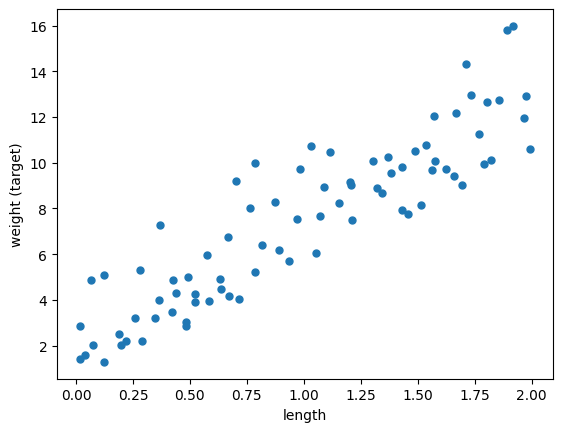

In [ ]:
plt.plot(X_train, y_train, ".", markersize=10)
plt.xlabel("length")
plt.ylabel("weight (target)");

y=ax+b

Let's plot a linear regression model on this dataset.

In [ ]:
grid = np.linspace(min(X_train)[0], max(X_train)[0], 1000)
grid = grid.reshape(-1, 1)

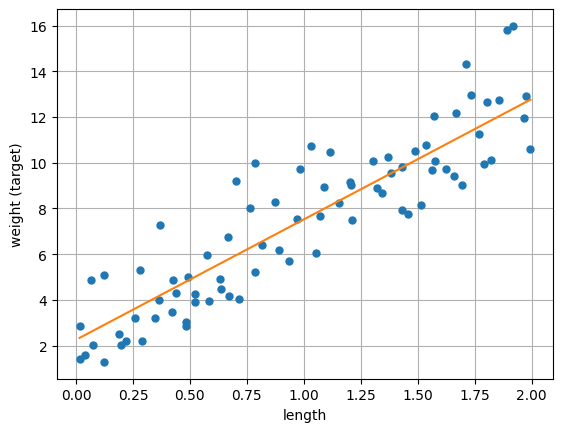

In [ ]:
from sklearn.linear_model import Ridge

r = Ridge()
r.fit(X_train, y_train)
plt.plot(X_train, y_train, ".", markersize=10)
plt.plot(grid, r.predict(grid))
plt.grid(True)
plt.xlabel("length")
plt.ylabel("weight (target)");

**The orange line is the learned linear model.**

### Prediction of linear regression

- Given a snake length, we can use the model above to predict the target (i.e., the weight of the snake).
- The prediction will be the corresponding weight on the orange line.

In [ ]:
snake_length = 0.75
r.predict([[snake_length]])

array([6.20683258])

#### What are we exactly learning?

- The model above is a line, which can be represented with a slope (i.e., coefficient or weight) and an intercept.
- For the above model, we can access the slope (i.e., coefficient or weight) and the intercept using `coef_` and `intercept_`, respectively.

In [ ]:
r.coef_  # r is our linear regression object

array([5.26370005])

In [ ]:
r.intercept_  # r is our linear regression object

np.float64(2.259057547817185)

### How are we making predictions?
- Given a feature value $x_1$ and learned coefficient $w_1$ and intercept $b$, we can get the prediction $\hat{y}$ with the following formula:
$$\hat{y} = w_1x_1 + b$$

In [ ]:
prediction = snake_length * r.coef_ + r.intercept_
prediction

array([6.20683258])

In [ ]:
r.predict([[snake_length]])

array([6.20683258])

Great! Now we exactly know how the model is making the prediction.

### Generalizing to more features
For more features, the model is a higher dimensional hyperplane and the general prediction formula looks as follows:

$\hat{y} =$ <font color="red">$w_1$</font> <font color="blue">$x_1$ </font> $+ \dots +$ <font color="red">$w_d$</font> <font color="blue">$x_d$</font> + <font  color="green"> $b$</font>

where,
- <font  color="blue"> ($x_1, \dots, x_d$) are input features </font>
- <font  color="red"> ($w_1, \dots, w_d$) are coefficients or weights </font> (learned from the data)
- <font  color="green"> $b$ is the bias which can be used to offset your hyperplane </font> (learned from the data)

### Example

- Suppose these are the coefficients learned by a linear regression model on a hypothetical housing price prediction dataset.

| Feature | Learned coefficient |
|--------------------|---------------------:|
| Bedrooms | 0.20 |
| Bathrooms| 0.11 |
| Square Footage | 0.002 |
| Age | -0.02 |

- Now given a new example, the target will be predicted as follows:
| Bedrooms | Bathrooms | Square Footage | Age |
|--------------------|---------------------|----------------|-----|
| 3                  | 2                   | 1875           | 66  |

$$\hat{y} = w_1x_1 + w_2x_2 + w_3x_3 + w_4x_4 + b$$

$$\text{predicted price}=  0.20 \times 3 + 0.11 \times 2 + 0.002 \times 1875 + (-0.02) \times 66 + b$$

When we call `fit`, a coefficient or weight is learned for each feature which tells us the role of that feature in prediction. These coefficients are learned from the training data.  

```{important}
In linear models for regression, the model is a line for a single feature, a plane for two features, and a hyperplane for higher dimensions.
```

## Linear Regression and Ridge



- `scikit-learn` has a model called `LinearRegression` for linear regression.
- But if we use this "vanilla" version of linear regression, it may result in large coefficients and unexpected results.
- So instead of using `LinearRegression`, we will always use another linear model called `Ridge`, which is a linear regression model with a complexity hyperparameter `alpha`.

- `LinearRegression` minimizes only the sum of squared errors, which can lead to overfitting if the number of features is large or if the dataset is small.

- `Ridge` adds a penalty term using `alpha`, preventing the model from learning excessively large weights, making it more generalizable.

- If we set `alpha`=0 that is the same as using LinearRegression.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression  # could be used too, but not suggested

#### Data

Let's use `sklearn`'s built in regression dataset, the Boston Housing dataset. The task associated with this dataset is to predict the median value of homes in several Boston neighborhoods in the 1970s, using information such as crime rate in the neighbourhood, average number of rooms, proximity to the Charles River, highway accessibility, and so on.

In [ ]:
from sklearn.datasets import fetch_california_housing


california = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    california.data, california.target, test_size=0.2
)
pd.DataFrame(X_train, columns=california.feature_names)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.0000,52.0,5.303030,1.082251,725.0,3.138528,38.03,-121.88
1,2.0000,52.0,5.506410,1.134615,1026.0,3.288462,34.00,-118.30
2,4.0474,30.0,5.419355,1.006452,858.0,2.767742,37.31,-121.94
3,3.2794,7.0,5.546473,1.044166,5146.0,3.392221,34.46,-117.20
4,2.5551,35.0,4.018487,1.016807,1886.0,3.169748,37.35,-121.86
...,...,...,...,...,...,...,...,...
16507,3.0185,17.0,4.205479,0.863014,434.0,1.981735,34.61,-120.16
16508,12.6320,5.0,7.462963,0.888889,208.0,3.851852,34.44,-119.31
16509,3.9808,20.0,5.678689,1.006557,999.0,3.275410,38.28,-121.20
16510,5.8195,25.0,6.585513,0.961771,1645.0,3.309859,33.71,-117.97


In [ ]:
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
y_train

array([1.014, 1.28 , 2.805, ..., 1.602, 2.861, 1.593])

#### `Ridge` on the California housing dataset


In [ ]:
pipe = make_pipeline(StandardScaler(), Ridge())
scores = cross_validate(pipe, X_train, y_train, return_train_score=True)
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.006924,0.001583,0.599492,0.608050
1,0.005849,0.001428,0.613507,0.604619
2,0.006104,0.001387,0.598100,0.608468
3,0.005692,0.002141,0.612621,0.604797
4,0.006866,0.001426,0.601790,0.606902


#### Hyperparameter `alpha` of `Ridge`

- Ridge has hyperparameters just like the rest of the models we learned.
- The alpha hyperparameter is what makes `Ridge` different from vanilla `LinearRegression`.
- `alpha` controls the fundamental tradeoff.

```{note}
If we set alpha=0 that is the same as using LinearRegression.
```

Let's examine the effect of `alpha` on the fundamental tradeoff.

In [ ]:
scores_dict = {
    "alpha": 10.0 ** np.arange(-3, 6, 1),
    "mean_train_scores": list(),
    "mean_cv_scores": list(),
}
for alpha in scores_dict["alpha"]:
    pipe_ridge = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    scores = cross_validate(pipe_ridge, X_train, y_train, return_train_score=True)
    scores_dict["mean_train_scores"].append(scores["train_score"].mean())
    scores_dict["mean_cv_scores"].append(scores["test_score"].mean())

results_df = pd.DataFrame(scores_dict)

In [ ]:
results_df

,alpha,mean_train_scores,mean_cv_scores
0,0.001,0.606567,0.605101
1,0.010,0.606567,0.605101
2,0.100,0.606567,0.605101
3,1.000,0.606567,0.605102
4,10.000,0.606557,0.605100
5,100.000,0.605696,0.604320
6,1000.000,0.579432,0.578523
7,10000.000,0.431137,0.430868
8,100000.000,0.116167,0.115956


Here we do not really see overfitting but in general,
- larger `alpha` $\rightarrow$ likely to underfit
- smaller `alpha` $\rightarrow$ likely to overfit

#### Coefficients and intercept

The model learns
- coefficients associated with each feature
- the intercept or bias

Let's examine the coefficients learned by the model.

In [ ]:
pipe_ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
pipe_ridge.fit(X_train, y_train)
coeffs = pipe_ridge.named_steps["ridge"].coef_

In [ ]:
pd.DataFrame(data=coeffs, index=california.feature_names, columns=["Coefficients"])

,Coefficients
MedInc,0.827039
HouseAge,0.117058
AveRooms,-0.265273
AveBedrms,0.307521
Population,-0.003194
AveOccup,-0.039498
Latitude,-0.895963
Longitude,-0.866110


- The model also learns an intercept (bias).
- For each prediction, we are adding this amount irrespective of the feature values.  

In [ ]:
pipe_ridge.named_steps["ridge"].intercept_

np.float64(2.0667579112160865)

Can we use this information to interpret model predictions?

### Interpretation of coefficients

- One of the main advantages of linear models is that they are relatively easy to interpret.
- We have one coefficient per feature which kind of describes the role of the feature in the prediction according to the model.

There are two pieces of information in the coefficients based on

- Sign
- Magnitude

### Sign of the coefficients

In the example below, for instance:
- MedInc (median income) has a **positive coefficient**
    - the prediction will be proportional to the feature value; as MedInc gets **bigger**, the median house value gets **bigger**
- AveRooms (Average number of rooms) has a **negative coefficient**
    - the prediction will be inversely proportional to the feature value; as AveRooms gets **bigger**, the median house value gets **smaller**

In [ ]:
pd.DataFrame(data=coeffs, index=california.feature_names, columns=["Coefficients"])

,Coefficients
MedInc,0.827039
HouseAge,0.117058
AveRooms,-0.265273
AveBedrms,0.307521
Population,-0.003194
AveOccup,-0.039498
Latitude,-0.895963
Longitude,-0.866110


#### Magnitude of the coefficients

- Bigger magnitude $\rightarrow$ bigger impact on the prediction
- In the example below, both MedInc and AveBedrms have a positive impact on the prediction but MedInc would have a bigger positive impact because it's feature value is going to be multiplied by a number with a bigger magnitude.

In [ ]:
data = {
    "coefficient": pipe_ridge.named_steps["ridge"].coef_.tolist(),
    "magnitude": np.absolute(pipe_ridge.named_steps["ridge"].coef_.tolist()),
}
coef_df = pd.DataFrame(data, index=california.feature_names).sort_values(
    "magnitude", ascending=False
)
coef_df

,coefficient,magnitude
Latitude,-0.895963,0.895963
Longitude,-0.866110,0.866110
MedInc,0.827039,0.827039
AveBedrms,0.307521,0.307521
AveRooms,-0.265273,0.265273
HouseAge,0.117058,0.117058
AveOccup,-0.039498,0.039498
Population,-0.003194,0.003194
